In [93]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from arch import arch_model

import scipy.stats as stats

import utils.Features as util


In [94]:
data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
data_OOS = yf.download("^GSPC", start="2024-01-01", end="2025-01-01")

C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\1755187736.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\1755187736.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_OOS = yf.download("^GSPC", start="2024-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [95]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


In [96]:
df = data.copy()
df_OOS = data_OOS.copy()
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
df_OOS.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

In [97]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,1455.219971,1478.000000,1438.359985,1469.250000,931800000
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000


<Axes: title={'center': 'Close Price Returns'}, xlabel='Date'>

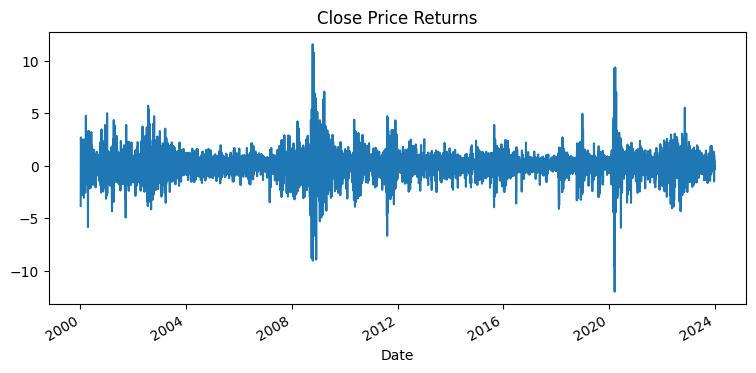

In [98]:
returns = df["Close"].pct_change().dropna() * 100  # Daily returns in percentage
returns_OOS = df_OOS["Close"].pct_change().dropna() * 100  # Daily returns in percentage

returns.plot(title='Close Price Returns', figsize=(9,4))

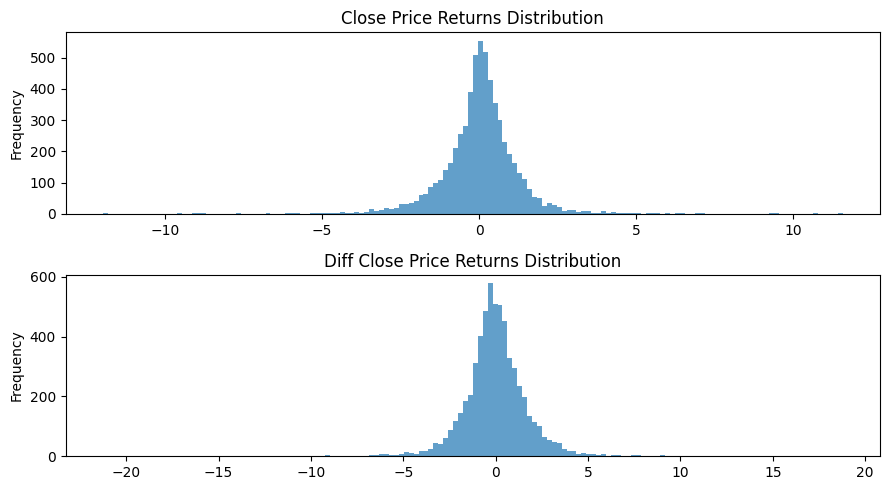

In [99]:
fig, ax = plt.subplots(2,1, figsize=(9,5))

returns.plot(kind='hist', title='Close Price Returns Distribution', bins=150, alpha=0.7, ax=ax[0])
returns.diff().plot(kind='hist', title='Diff Close Price Returns Distribution', bins=150, alpha=0.7, ax=ax[1])
# np.log(returns).plot(kind='hist', title='Log Close Price Returns Distribution', bins=150, alpha=0.7, ax=ax[2])
plt.tight_layout()
plt.show()


In [100]:
df['Close_Returns'] = returns
df['Vol_Proxy'] = returns.abs()


df_OOS['Close_Returns'] = returns_OOS
df_OOS['Vol_Proxy'] = returns_OOS.abs()


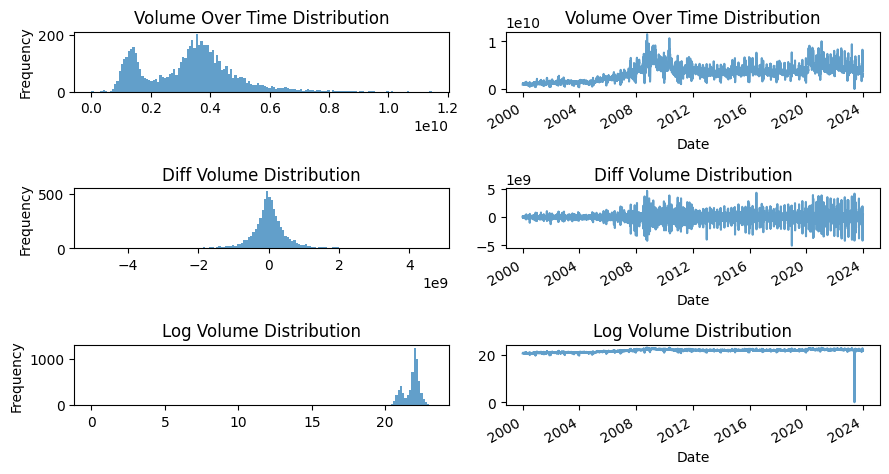

In [101]:
fig, ax = plt.subplots(3,2, figsize=(9,5))

df["Volume"].plot(kind='hist', title='Volume Over Time Distribution', bins=150, alpha=0.7, ax=ax[0,0])
df["Volume"].diff().plot(kind='hist', title='Diff Volume Distribution', bins=150, alpha=0.7, ax=ax[1,0])
np.log(df["Volume"] + 1).plot(kind='hist', title='Log Volume Distribution', bins=150, alpha=0.7, ax=ax[2,0])


df["Volume"].plot(kind='line', title='Volume Over Time Distribution',alpha=0.7, ax=ax[0,1])
df["Volume"].diff().plot(kind='line', title='Diff Volume Distribution',alpha=0.7, ax=ax[1,1])
np.log(df["Volume"] + 1).plot(kind='line', title='Log Volume Distribution',alpha=0.7, ax=ax[2,1])
plt.tight_layout()
plt.show()


In [102]:
df['Diff_Volume'] = df['Volume'].diff()
df.dropna(inplace=True)

df_OOS['Diff_Volume'] = df_OOS['Volume'].diff()
df_OOS.dropna(inplace=True)

In [103]:
df['Neg_Ret'] = df['Close'].pct_change().clip(upper=0.0)
df['Neg_Ret'] = df['Neg_Ret'].fillna(0.0)


df_OOS['Neg_Ret'] = df_OOS['Close'].pct_change().clip(upper=0.0)
df_OOS['Neg_Ret'] = df_OOS['Neg_Ret'].fillna(0.0)


In [104]:
df.isna().sum()

Close            0
High             0
Low              0
Open             0
Volume           0
Close_Returns    0
Vol_Proxy        0
Diff_Volume      0
Neg_Ret          0
dtype: int64

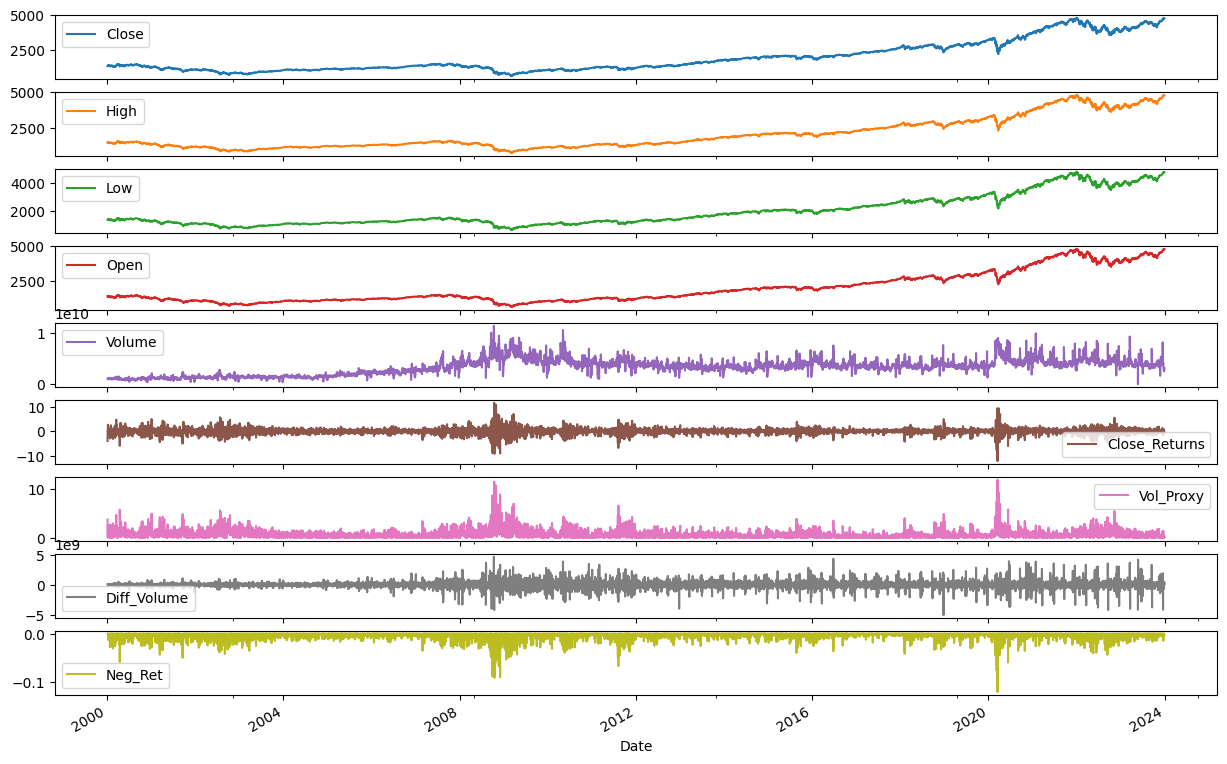

In [105]:
df.plot(subplots=True, figsize=(15,10))
plt.show()

c:\Users\yahya\Desktop\MR Project\Code\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\yahya\Desktop\MR Project\Code\.venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


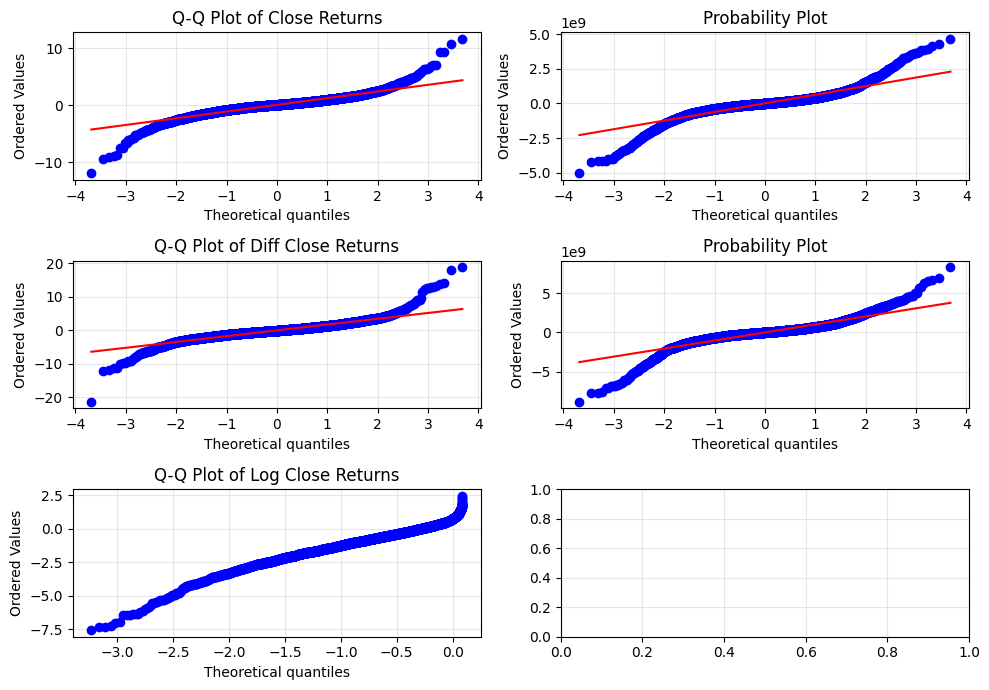

In [106]:
fig, ax = plt.subplots(3,2, figsize=(10, 7))

stats.probplot(df["Close_Returns"], dist="norm", plot=ax[0,0])
stats.probplot((df["Close_Returns"]).diff().dropna(), dist="norm", plot=ax[1, 0])
stats.probplot(np.log(df["Close_Returns"]), dist="norm", plot=ax[2, 0])

ax[0,0].set_title("Q-Q Plot of Close Returns")
ax[1,0].set_title("Q-Q Plot of Diff Close Returns")
ax[2,0].set_title("Q-Q Plot of Log Close Returns")

stats.probplot(df["Diff_Volume"].dropna(), dist="norm", plot=ax[0,1])
stats.probplot((df["Diff_Volume"]).diff().dropna(), dist="norm", plot=ax[1, 1])
# stats.probplot(np.log(df["Diff_Volume"].dropna() + 1), dist="norm", plot=ax[2, 1])

for a in ax.ravel():
    a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [107]:
for col in df.columns[:]:
    print(f"{col} - Mean: {df[col].mean()}, Std: {df[col].std()}")
    print("ADF Test:")
    result = adfuller(df[col])
    print(f"\tADF Statistic: {result[0]}")
    print(f"\tp-value: {result[1]}")
    print(f"\tUsed Lag: {result[2]}")
    print(f"\tnobs: {result[3]}")

Close - Mean: 1973.6724301711702, Std: 1061.4028260464104
ADF Test:
	ADF Statistic: 1.5344751866999333
	p-value: 0.997647052527666
	Used Lag: 32
	nobs: 6003
High - Mean: 1985.0393213938214, Std: 1066.4708392756954
ADF Test:
	ADF Statistic: 1.5247642039859268
	p-value: 0.9976133512950586
	Used Lag: 34
	nobs: 6001
Low - Mean: 1960.88088167164, Std: 1055.5978656274497
ADF Test:
	ADF Statistic: 1.417948081594245
	p-value: 0.9971941712188653
	Used Lag: 33
	nobs: 6002
Open - Mean: 1973.3857412470975, Std: 1061.1320321560654
ADF Test:
	ADF Statistic: 1.5429507733398513
	p-value: 0.9976759175429503
	Used Lag: 31
	nobs: 6004
Volume - Mean: 3327089133.5321403, Std: 1509723279.7087934
ADF Test:
	ADF Statistic: -3.0616783323135697
	p-value: 0.02952223820378465
	Used Lag: 32
	nobs: 6003
Close_Returns - Mean: 0.027322150712152504, Std: 1.2360110669819382
ADF Test:
	ADF Statistic: -18.915263075643377
	p-value: 0.0
	Used Lag: 17
	nobs: 6018
Vol_Proxy - Mean: 0.8185269721147133, Std: 0.9264839774300043

In [108]:
for col in df.columns[:]:
    print(f"{col} - Mean: {df[col].mean()}, Std: {df[col].std()}")
    print("KPSS Test:")
    result = kpss(df[col])
    print(f"\tKPSS Statistic: {result[0]}")
    print(f"\tp-value: {result[1]}")
    print(f"\tUsed Lag: {result[2]}")
    print(f"\tnobs: {result[3]}")

Close - Mean: 1973.6724301711702, Std: 1061.4028260464104
KPSS Test:
	KPSS Statistic: 10.501531976929995
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
High - Mean: 1985.0393213938214, Std: 1066.4708392756954
KPSS Test:
	KPSS Statistic: 10.493500627718738
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Low - Mean: 1960.88088167164, Std: 1055.5978656274497
KPSS Test:
	KPSS Statistic: 10.505327772897628
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Open - Mean: 1973.3857412470975, Std: 1061.1320321560654
KPSS Test:
	KPSS Statistic: 10.49952591154559
	p-value: 0.01
	Used Lag: 45
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Volume - Mean: 3327089133.5321403, Std: 1509723279.7087934
KPSS Test:
	KPSS Statistic: 6.48963489620342
	p-value: 0.01
	Used Lag: 44
	nobs: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Close_Returns - Mean: 0

C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df[col])
C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df[col])
C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(df[col])
C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\31060911.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned

In [109]:
df

,Close,High,Low,Open,Volume,Close_Returns,Vol_Proxy,Diff_Volume,Neg_Ret
Date,,,,,,,,,
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,-3.834467,3.834467,77200000.0,0.000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,0.192218,0.192218,76500000.0,0.000000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,0.095568,0.095568,6800000.0,0.000000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,2.709040,2.709040,132900000.0,0.000000
2000-01-10,1457.599976,1464.359985,1441.469971,1441.469971,1064800000,1.118997,1.118997,-160400000.0,0.000000
...,...,...,...,...,...,...,...,...,...
2023-12-22,4754.629883,4772.939941,4736.770020,4753.919922,3046770000,0.166006,0.166006,-384410000.0,0.000000
2023-12-26,4774.750000,4784.720215,4758.450195,4758.859863,2513910000,0.423169,0.423169,-532860000.0,0.000000
2023-12-27,4781.580078,4785.390137,4768.899902,4773.450195,2748450000,0.143046,0.143046,234540000.0,0.000000


In [110]:
def create_sequences(
    data: pd.DataFrame,
    lookback: int,
    horizon: int,
    feature_cols: list[str] = ["Vol_Diff"],
    predict_col_index: int = 0,
) -> tuple[np.ndarray, np.ndarray]:
    """Create sequences of data for time series forecasting.

    Args:
        data (pd.DataFrame): The input data containing features.
        lookback (int): The number of past timesteps to include in each input sequence.
        horizon (int): The number of future timesteps to predict.

    Returns:
        Tuple[np.ndarray]: The input sequences (X) and the corresponding targets (y).
    """
    X, y = [], []

    data_values = data[feature_cols].values

    for i in range(len(data) - lookback - horizon):
        window = data_values[i : i + lookback]
        future_window = data_values[i + lookback : i + lookback + horizon, predict_col_index]

        X.append(window)
        y.append(future_window)

    return np.array(X), np.array(y)


In [111]:
df

,Close,High,Low,Open,Volume,Close_Returns,Vol_Proxy,Diff_Volume,Neg_Ret
Date,,,,,,,,,
2000-01-04,1399.420044,1455.219971,1397.430054,1455.219971,1009000000,-3.834467,3.834467,77200000.0,0.000000
2000-01-05,1402.109985,1413.270020,1377.680054,1399.420044,1085500000,0.192218,0.192218,76500000.0,0.000000
2000-01-06,1403.449951,1411.900024,1392.099976,1402.109985,1092300000,0.095568,0.095568,6800000.0,0.000000
2000-01-07,1441.469971,1441.469971,1400.729980,1403.449951,1225200000,2.709040,2.709040,132900000.0,0.000000
2000-01-10,1457.599976,1464.359985,1441.469971,1441.469971,1064800000,1.118997,1.118997,-160400000.0,0.000000
...,...,...,...,...,...,...,...,...,...
2023-12-22,4754.629883,4772.939941,4736.770020,4753.919922,3046770000,0.166006,0.166006,-384410000.0,0.000000
2023-12-26,4774.750000,4784.720215,4758.450195,4758.859863,2513910000,0.423169,0.423169,-532860000.0,0.000000
2023-12-27,4781.580078,4785.390137,4768.899902,4773.450195,2748450000,0.143046,0.143046,234540000.0,0.000000


In [113]:
HORIZON = 1
LOOKBACK = 21
feature_cols = ['Vol_Proxy', 'Diff_Volume', "Neg_Ret"]

X_raw, y_raw = create_sequences(df, lookback=LOOKBACK, horizon=HORIZON, feature_cols=feature_cols, predict_col_index=0)
X_OOS, y_OOS = create_sequences(df_OOS, lookback=LOOKBACK, horizon=HORIZON, feature_cols=feature_cols, predict_col_index=0)

print(f"X shape: {X_raw.shape}  (Samples, Timesteps, Features)")
print(f"y shape: {y_raw.shape}  (Samples, Horizon)")

print("=" * 60, f"Out of scope Data", "=" * 60, sep="\n")
print(f"X2 shape: {X_OOS.shape}  (Samples, Timesteps, Features)")
print(f"y2 shape: {y_OOS.shape}  (Samples, Horizon)")

X shape: (6014, 21, 3)  (Samples, Timesteps, Features)
y shape: (6014, 1)  (Samples, Horizon)
Out of scope Data
X2 shape: (229, 21, 3)  (Samples, Timesteps, Features)
y2 shape: (229, 1)  (Samples, Horizon)


In [114]:
n_sep = int(0.8 * X_raw.shape[0])

X_train, X_test = X_raw[:n_sep], X_raw[n_sep:]
y_train, y_test = y_raw[:n_sep], y_raw[n_sep:]

X_scaler = StandardScaler()
y_scaler = StandardScaler()

# X_scaler.fit(X_train.reshape(-1, X_train.shape[-1]))
# y_scaler.fit(y_train.reshape(-1, y_train.shape[-1]))

X_train_scaled = X_scaler.fit_transform(
    X_train.reshape(-1, X_train.shape[-1])
).reshape(X_train.shape)

X_test_scaled = X_scaler.transform(
    X_test.reshape(-1, X_test.shape[-1])
).reshape(X_test.shape)

y_train_scaled = y_scaler.fit_transform(
    y_train.reshape(-1, y_train.shape[-1])
).reshape(y_train.shape)

y_test_scaled = y_scaler.transform(
    y_test.reshape(-1, y_test.shape[-1])
).reshape(y_test.shape)

print("Data shapes:")
print("Raw Data:")
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Test set: X={X_test.shape}, y={y_test.shape}")

print("Scaled Data:")
print(f"Training set: X={X_train_scaled.shape}, y={y_train_scaled.shape}")
print(f"Test set: X={X_test_scaled.shape}, y={y_test_scaled.shape}")

Data shapes:
Raw Data:
Training set: X=(4811, 21, 3), y=(4811, 1)
Test set: X=(1203, 21, 3), y=(1203, 1)
Scaled Data:
Training set: X=(4811, 21, 3), y=(4811, 1)
Test set: X=(1203, 21, 3), y=(1203, 1)


In [115]:
X_OOS_scaled = X_scaler.transform(
    X_OOS.reshape(-1, X_OOS.shape[-1])
).reshape(X_OOS.shape)

y_OOS_scaled = y_scaler.transform(
    y_OOS.reshape(-1, y_OOS.shape[-1])
).reshape(y_OOS.shape)

print("Out of Scope Data shapes:")
print("X_OOS:", X_OOS_scaled.shape)
print("y_OOS_scaled:", y_OOS_scaled.shape)

Out of Scope Data shapes:
X_OOS: (229, 21, 3)
y_OOS_scaled: (229, 1)


In [116]:
INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])
OUTPUT_SIZE = y_train.shape[1]

print(f"Input shape: {INPUT_SHAPE}")
print(f"Output size: {OUTPUT_SIZE}")

Input shape: (21, 3)
Output size: 1


In [117]:
model = Sequential(
    [
        Input(shape=INPUT_SHAPE),
        GRU(units=64, return_sequences=False, activation="tanh", recurrent_dropout=0.0),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(OUTPUT_SIZE, activation="linear"),
    ]
)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

In [118]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

In [119]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7779 - mae: 0.6003 - val_loss: 0.8839 - val_mae: 0.6103 - learning_rate: 0.0010
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7245 - mae: 0.5813 - val_loss: 0.8736 - val_mae: 0.6019 - learning_rate: 0.0010
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.7082 - mae: 0.5785 - val_loss: 0.8902 - val_mae: 0.6026 - learning_rate: 0.0010
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6881 - mae: 0.5771 - val_loss: 0.9779 - val_mae: 0.6228 - learning_rate: 0.0010
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.6953 - mae: 0.5750 - val_loss: 0.9020 - val_mae: 0.6190 - learning_rate: 0.0010
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.6943 - mae: 0.5748 - val_loss: 0.9001 - val_mae: 0.6099 - learning_rate: 0.0010
Epoch 7/100
145/151 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6993 - mae: 0.5801
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.00

In [121]:
y_pred_scaled: np.ndarray = model.predict(X_test_scaled)


y_pred = y_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_pred_scaled.shape)

y_true = y_scaler.inverse_transform(
    y_test_scaled.reshape(-1, y_test.shape[-1])
).reshape(y_test_scaled.shape)


y_pred_df = pd.DataFrame(
    y_pred[:, 0], index=df.index[LOOKBACK + n_sep : -HORIZON], columns=["Predicted_Vol_Proxy"]
)
y_true_df = pd.DataFrame(
    y_true[:, 0], index=df.index[LOOKBACK + n_sep : -HORIZON], columns=["Actual_Vol_Proxy"]
)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


<Figure size 1400x600 with 0 Axes>

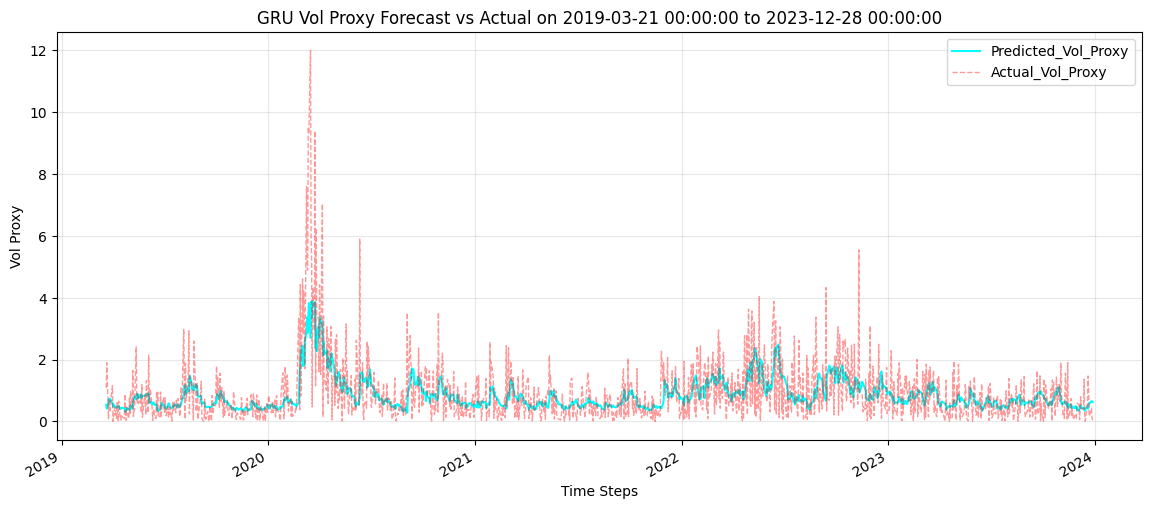

Sample 10 Actual :    [1.0852481  1.89745012 0.08390207 0.71827259 0.46443249]...
Sample 10 Predicted : [0.53772604 0.41288176 0.6207066  0.7271478  0.6737828 ]...


In [122]:
plt.figure(figsize=(14, 6))

limit = 2000

fig, ax = plt.subplots(figsize=(14, 6))
y_pred_df.plot(ax=ax, color="cyan", legend=True)
y_true_df.plot(ax=ax, color="red", linewidth=1, linestyle="--", legend=True, alpha=0.4)

plt.title(
    f"GRU Vol Proxy Forecast vs Actual on {y_pred_df.index[0]} to {y_pred_df.index[-1]}"
)
plt.xlabel("Time Steps")
plt.ylabel("Vol Proxy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Sample 10 Actual :    {y_test[:5,0]}...")
print(f"Sample 10 Predicted : {y_pred[:5,0]}...")



### Metrics on Close Returns Prediction (GRU)

In [126]:
print("=" * 60, f"Evaluating on {y_true_df.index[0]} to {y_true_df.index[-1]} Data", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_true_df[1:]["Actual_Vol_Proxy"], y_true_df["Actual_Vol_Proxy"].shift(1).dropna())
naive_mae = mean_absolute_error(y_true_df[1:]["Actual_Vol_Proxy"], y_true_df["Actual_Vol_Proxy"].shift(1).dropna())
naive_r2 = r2_score(y_true_df[1:]["Actual_Vol_Proxy"], y_true_df["Actual_Vol_Proxy"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_true_df["Actual_Vol_Proxy"], y_pred_df["Predicted_Vol_Proxy"])
mae = mean_absolute_error(y_true_df["Actual_Vol_Proxy"], y_pred_df["Predicted_Vol_Proxy"])
r2 = r2_score(y_true_df["Actual_Vol_Proxy"], y_pred_df["Predicted_Vol_Proxy"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

# print("-" * 40)
# print("Absolute differences between Naive Baseline and Model (10 decimal places):")
# print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2019-03-21 00:00:00 to 2023-12-28 00:00:00 Data
Naive Baseline RMSE: 1.1286767044985202
Naive Baseline MAE: 0.7578007219040116
Naive Baseline R²: -0.20295593503462395
----------------------------------------
Model RMSE: 0.8384943943616604
Model MAE: 0.5399748570245737
Model R²: 0.33555453516614453


In [66]:
# ============================================================
# Evaluating on 2019-03-21 00:00:00 to 2023-12-28 00:00:00 Data
# ============================================================
# Naive Baseline RMSE: 2.101006567357449
# Naive Baseline MAE: 1.3165015544717782
# Naive Baseline R²: -1.3837875856660364
# ----------------------------------------
# Model RMSE: 1.3509914379464476
# Model MAE: 0.886612534589902
# Model R²: 0.01401318433929033

## Testing on out-of-sample data

In [129]:
y_OOS_pred: np.ndarray = model.predict(X_OOS_scaled)


y_OOS_pred = y_scaler.inverse_transform(
    y_OOS_pred.reshape(-1, y_OOS_scaled.shape[-1])
).reshape(y_OOS_pred.shape)

# y_true = y_OOS_scaled

y_OOS_pred_df = pd.DataFrame(
    y_OOS_pred[:, 0], index=df_OOS.index[LOOKBACK : -HORIZON], columns=["Predicted_Vol_Proxy"]
)
y_OOS_df = pd.DataFrame(
    y_OOS[:, 0], index=df_OOS.index[LOOKBACK : -HORIZON], columns=["Actual_Vol_Proxy"]
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


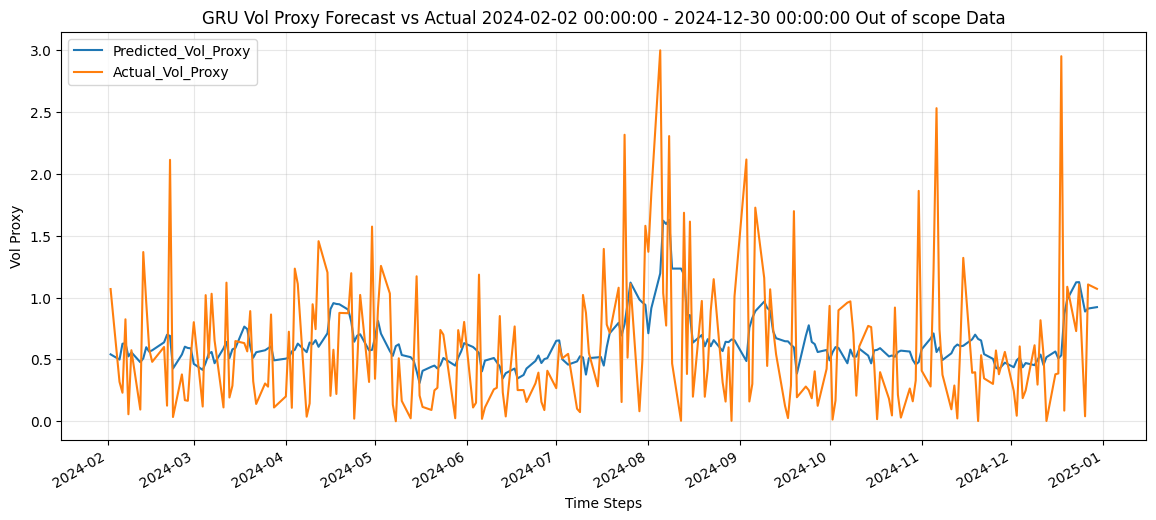

In [130]:
fig, ax = plt.subplots(figsize=(14, 6))

y_OOS_pred_df[["Predicted_Vol_Proxy"]].plot(ax=ax)
y_OOS_df[["Actual_Vol_Proxy"]].plot(ax=ax)

plt.title(f"GRU Vol Proxy Forecast vs Actual {y_OOS_df.index[0]} - {y_OOS_df.index[-1]} Out of scope Data")
plt.xlabel("Time Steps")
plt.ylabel("Vol Proxy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [131]:
print("=" * 60, f"Evaluating on {y_OOS_df.index[0]} to {y_OOS_df.index[-1]} Data (Out of scope)", "=" * 60, sep="\n")
naive_mse = mean_squared_error(y_OOS_df[1:]["Actual_Vol_Proxy"], y_OOS_df["Actual_Vol_Proxy"].shift(1).dropna())
naive_mae = mean_absolute_error(y_OOS_df[1:]["Actual_Vol_Proxy"], y_OOS_df["Actual_Vol_Proxy"].shift(1).dropna())
naive_r2 = r2_score(y_OOS_df[1:]["Actual_Vol_Proxy"], y_OOS_df["Actual_Vol_Proxy"].shift(1).dropna())
print(f"Naive Baseline RMSE: {np.sqrt(naive_mse)}")
print(f"Naive Baseline MAE: {naive_mae}")
print(f"Naive Baseline R²: {naive_r2}")

print("-" * 40)

mse = mean_squared_error(y_OOS_df["Actual_Vol_Proxy"], y_OOS_pred_df["Predicted_Vol_Proxy"])
mae = mean_absolute_error(y_OOS_df["Actual_Vol_Proxy"], y_OOS_pred_df["Predicted_Vol_Proxy"])
r2 = r2_score(y_OOS_df["Actual_Vol_Proxy"], y_OOS_pred_df["Predicted_Vol_Proxy"])
print(f"Model RMSE: {np.sqrt(mse)}")
print(f"Model MAE: {mae}")
print(f"Model R²: {r2}")

# print("-" * 40)
# print("Absolute differences between Naive Baseline and Model (10 decimal places):")
# print(f"MSE: {abs(np.sqrt(naive_mse) - np.sqrt(mse)):.10f}\nMAE: {abs(naive_mae - mae):.10f}\nR²: {abs(naive_r2 - r2):.10f}")

Evaluating on 2024-02-02 00:00:00 to 2024-12-30 00:00:00 Data (Out of scope)
Naive Baseline RMSE: 0.7460241376163953
Naive Baseline MAE: 0.5473483213922832
Naive Baseline R²: -0.8885335278792466
----------------------------------------
Model RMSE: 0.5154367211966042
Model MAE: 0.3925279549740935
Model R²: 0.09750427688320185


In [70]:
# ============================================================
# Evaluating on 2024-02-02 00:00:00 to 2024-12-30 00:00:00 Data (Out of scope)
# ============================================================
# Naive Baseline RMSE: 1.1169017131122052
# Naive Baseline MAE: 0.8671769595280239
# Naive Baseline R²: -0.9332693354439245
# ----------------------------------------
# Model RMSE: 0.8137445293280818
# Model MAE: 0.6052787971402468
# Model R²: -0.02394648149234868

***
## <center>GARCH Model</center>
***

In [139]:
# 1. SETUP DATA FOR GARCH
# GARCH models work best on Returns.
# 'Rescale' is often needed: GARCH converges better if returns are * 100 (percentage).
returns_series = df['Close_Returns'] 

# Define the exact split point used in your GRU
# (Assuming 'n_sep' and 'LOOKBACK' variables are from your previous code)
# We need to ensure the Test sets align by Date Index.
split_date = df.index[n_sep + LOOKBACK] 

print(f"Training data up to: {split_date}")
print(returns_series.shape)

Training data up to: 2019-03-21 00:00:00
(6036,)


In [140]:
# 2. TRAIN GARCH
am = arch_model(returns_series, vol='Garch', p=1, o=0, q=1, dist='Normal')

# We split the data manually for the fit to ensure no leakage
train_returns = returns_series.loc[:split_date]
test_returns = returns_series.loc[split_date:]

# Fit only on TRAINING data
res = am.fit(last_obs=split_date, disp=True)

Iteration:      1,   Func. Count:      6,   Neg. LLF: 20882268199.021214
Iteration:      2,   Func. Count:     15,   Neg. LLF: 2684184108.2202263
Iteration:      3,   Func. Count:     22,   Neg. LLF: 9561.098443472278
Iteration:      4,   Func. Count:     29,   Neg. LLF: 6703.092124988125
Iteration:      5,   Func. Count:     35,   Neg. LLF: 6641.739141225917
Iteration:      6,   Func. Count:     41,   Neg. LLF: 6847.711117846289
Iteration:      7,   Func. Count:     47,   Neg. LLF: 6610.648148097367
Iteration:      8,   Func. Count:     53,   Neg. LLF: 6598.74220426304
Iteration:      9,   Func. Count:     58,   Neg. LLF: 6598.7106662538445
Iteration:     10,   Func. Count:     63,   Neg. LLF: 6598.710402540346
Iteration:     11,   Func. Count:     68,   Neg. LLF: 6598.710394630264
Iteration:     12,   Func. Count:     72,   Neg. LLF: 6598.7103946315565
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6598.710394630264
            Iterations: 1

In [141]:
# 3. FORECAST
# We use the model parameters fitted on Train data to forecast the Test data.
# 'horizon=1' means we predict the next day's volatility.
forecasts = res.forecast(start=split_date, reindex=False)

# Extract Conditional Volatility (Sigma)
# Note: The output is Variance, so we take sqrt.
# Also divide by 100 to get back to decimal scale (since we multiplied by 100 earlier)
garch_pred_vol = np.sqrt(forecasts.variance[split_date:]) / 100

# Align indices exactly with your GRU "y_true_df"
common_index = y_true_df.index.intersection(garch_pred_vol.index)

# Filter both to the common index
garch_pred_final = garch_pred_vol.loc[common_index]
actual_vol_proxy_final = y_true_df.loc[common_index, "Actual_Vol_Proxy"] 
gru_pred_final = y_pred_df.loc[common_index, "Predicted_Vol_Proxy"]

GROUND-TO-GROUND COMPARISON GRU vs GARCH(1,1) on data from 2019-03-21 00:00:00 to 2023-12-28 00:00:00
--- GRU (Your Model) Results ---
RMSE: 0.838494
MAE:  0.539975
R²:   0.335555
------------------------------
--- GARCH(1,1) Baseline Results ---
RMSE: 1.350576
MAE:  0.880829
R²:   -0.723841


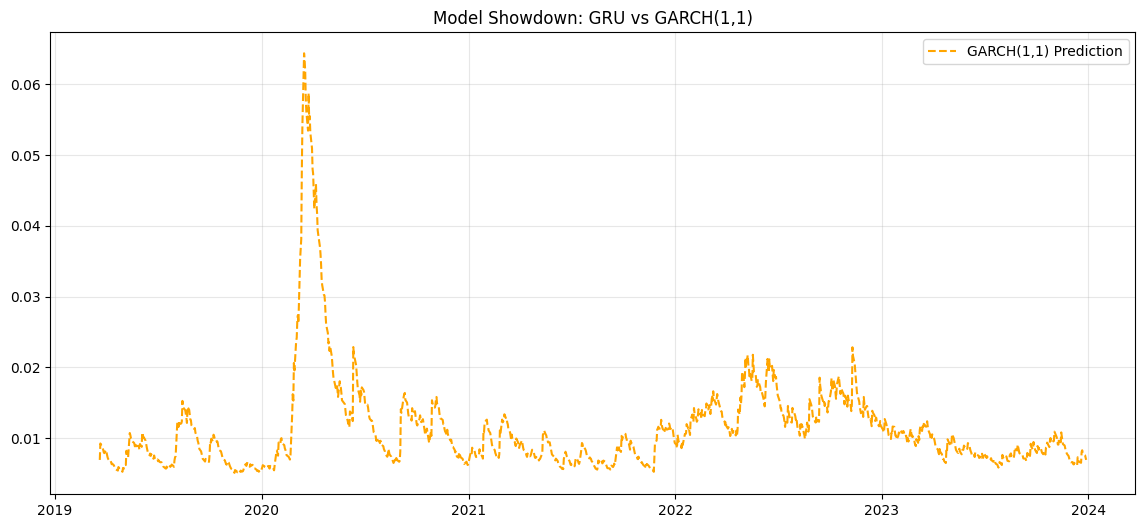

In [143]:
# 4. METRICS & COMPARISON
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Results ---")
    print(f"RMSE: {np.sqrt(mse):.6f}")
    print(f"MAE:  {mae:.6f}")
    print(f"R²:   {r2:.6f}")
    return np.sqrt(mse), mae, r2

print("="*30)
print(f"GROUND-TO-GROUND COMPARISON GRU vs GARCH(1,1) on data from {common_index[0]} to {common_index[-1]}")
print("="*30)

# Evaluate GRU
evaluate_model(actual_vol_proxy_final, gru_pred_final, "GRU (Your Model)")

print("-" * 30)

# Evaluate GARCH
# Note: GARCH predicts 'h_t', column name is usually 'h.1'
evaluate_model(actual_vol_proxy_final, garch_pred_final['h.1'], "GARCH(1,1) Baseline")

# %%
# 5. VISUALIZATION
plt.figure(figsize=(14, 6))
plt.plot(actual_vol_proxy_final.index, actual_vol_proxy_final, color='gray', alpha=0.4, label='Actual Close Returns')
plt.plot(gru_pred_final.index, gru_pred_final, color='cyan', label='GRU Prediction')
plt.plot(garch_pred_final.index, garch_pred_final['h.1'], color='orange', linestyle='--', label='GARCH(1,1) Prediction')

plt.title("Model Showdown: GRU vs GARCH(1,1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [75]:
# ==============================
# GROUND-TO-GROUND COMPARISON GRU vs GARCH(1,1) on data from 2019-03-21 00:00:00 to 2023-12-28 00:00:00
# ==============================
# --- GRU (Your Model) Results ---
# RMSE: 1.350991
# MAE:  0.886613
# R²:   0.014013
# ------------------------------
# --- GARCH(1,1) Baseline Results ---
# RMSE: 1.361409
# MAE:  0.891569
# R²:   -0.001252

C:\Users\yahya\AppData\Local\Temp\ipykernel_18072\4118152828.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Epoch 1/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.6513 - mae: 0.5477 - val_loss: 0.7242 - val_mae: 0.5498 - learning_rate: 0.0010
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.5859 - mae: 0.5237 - val_loss: 0.7304 - val_mae: 0.5417 - learning_rate: 0.0010
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.5690 - mae: 0.5217 - val_loss: 0.6936 - val_mae: 0.5371 - learning_rate: 0.0010
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.5792 - mae: 0.5213 - val_loss: 0.7102 - val_mae: 0.5469 - learning_rate: 0.0010
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.5486 - mae: 0.5154 - val_loss: 0.7068 - val_mae: 0.5404 - learning_rate: 0.0010
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.5582 - mae: 0.5173 - val_loss: 0.7285 - val_mae: 0.5574 - learning_rate: 0.0010
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.5522 - mae: 0.5146 - val_loss: 0.7315 - val_mae: 0.5382 - learning_rate:

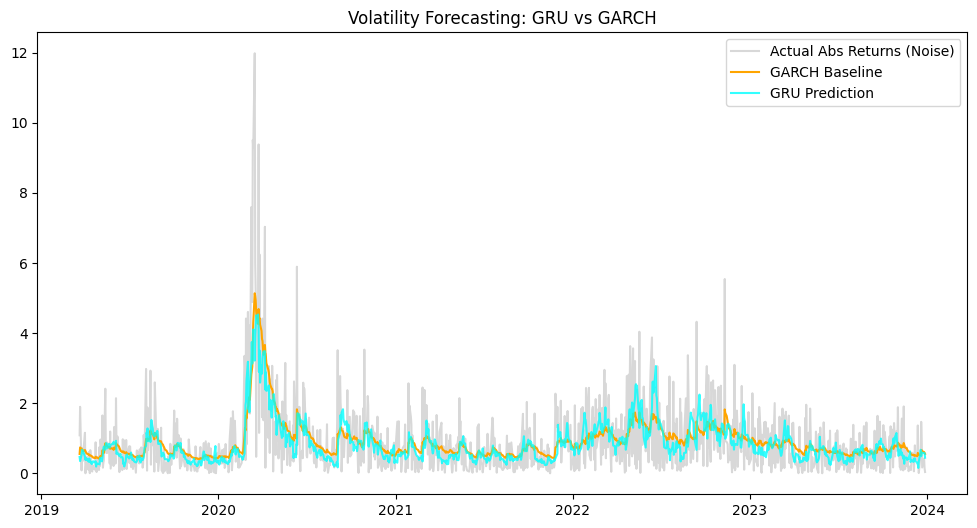

: 

In [ ]:
# %%
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, GRU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# 1. DATA PREPARATION
# ==========================================
data = yf.download("^GSPC", start="2000-01-01", end="2024-01-01")
df = data.copy()
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

# Calculate Returns
df['Returns'] = df['Close'].pct_change().dropna() * 100

# *** CRITICAL CHANGE ***
# We define the "Volatility Proxy" as the Absolute Return.
# This is what both models will try to predict.
df['Vol_Proxy'] = df['Returns'].abs()

# Features for GRU
df['Diff_Volume'] = df['Volume'].diff()
df['Neg_Ret'] = df['Returns'].clip(upper=0.0) # Leverage effect
df.dropna(inplace=True)

# ==========================================
# 2. SPLITTING (Aligning Train/Test)
# ==========================================
HORIZON = 1
LOOKBACK = 21

# Define features: We use returns to predict volatility
feature_cols = ['Vol_Proxy', 'Diff_Volume', 'Neg_Ret'] 
# Target is now MAGNITUDE
target_col = 'Vol_Proxy' 

# Create Sequences
def create_sequences(data, lookback, horizon, feat_cols, target_col):
    data_x = data[feat_cols].values
    data_y = data[target_col].values
    X, y = [], []
    for i in range(len(data) - lookback - horizon):
        X.append(data_x[i : i + lookback])
        y.append(data_y[i + lookback : i + lookback + horizon])
    return np.array(X), np.array(y)

X, y = create_sequences(df, LOOKBACK, HORIZON, feature_cols, target_col)

# Split Index
n_sep = int(0.8 * len(X))
split_date_index = df.index[n_sep + LOOKBACK] # Save the date for GARCH

X_train, X_test = X[:n_sep], X[n_sep:]
y_train, y_test = y[:n_sep], y[n_sep:]

# Scale
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train.reshape(-1, len(feature_cols))).reshape(X_train.shape)
X_test_scaled = X_scaler.transform(X_test.reshape(-1, len(feature_cols))).reshape(X_test.shape)

# We do NOT scale y (Target) for clearer interpretation, 
# or we scale and inverse transform later. Let's keep it unscaled for direct comparison with GARCH.

# ==========================================
# 3. TRAIN GRU (Predicting MAGNITUDE)
# ==========================================
model = Sequential([
    Input(shape=(LOOKBACK, len(feature_cols))),
    GRU(64, activation='tanh', return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear') # Output is strictly positive theoretically, linear allows learning
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]
# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100, # Reduced for speed in snippet
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Predict
gru_pred = model.predict(X_test_scaled)

# ==========================================
# 4. TRAIN GARCH (The Baseline)
# ==========================================
# GARCH needs the original returns series
returns_series = df['Returns']

# Fit GARCH only on Training Data (Up to split_date)
# We align the split exactly with the GRU
am = arch_model(returns_series, vol='Garch', p=1, o=0, q=1, dist='Normal')
res = am.fit(last_obs=split_date_index, disp='off')

# Forecast the Test Period
# Horizon=1 means "Next Day"
forecasts = res.forecast(start=split_date_index, reindex=False)

# Get GARCH Sigma (Conditional Volatility)
garch_pred = np.sqrt(forecasts.variance[split_date_index:])

# ==========================================
# 5. ALIGN AND COMPARE
# ==========================================
# Align indices
# GRU Y-test index (Actual)
test_index = df.index[n_sep + LOOKBACK : n_sep + LOOKBACK + len(y_test)]

# Create DataFrame for Comparison
comparison_df = pd.DataFrame(index=test_index)
comparison_df['Actual_Abs_Return'] = y_test.flatten()
comparison_df['GRU_Prediction'] = gru_pred.flatten()

# Merge GARCH (It might have slightly different length due to windowing, so we join on index)
comparison_df = comparison_df.join(garch_pred['h.1'], how='inner')
comparison_df.rename(columns={'h.1': 'GARCH_Prediction'}, inplace=True)
# Scale GARCH sigma to match the "Mean Absolute Deviation" scale
# Metrics
def get_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"RMSE: {np.sqrt(mse):.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")

print("\n"+"="*40)
print("GROUND-TO-GROUND COMPARISON (Target: Abs Returns)")
print("="*40)

comparison_df['GARCH_Prediction'] = comparison_df['GARCH_Prediction'] * np.sqrt(2/np.pi)
get_metrics(comparison_df['Actual_Abs_Return'], comparison_df['GRU_Prediction'], "GRU Model")
get_metrics(comparison_df['Actual_Abs_Return'], comparison_df['GARCH_Prediction'], "GARCH(1,1)")

# Plot
plt.figure(figsize=(12, 6))
# Plot actual as gray noise
plt.plot(comparison_df.index, comparison_df['Actual_Abs_Return'], color='gray', alpha=0.3, label='Actual Abs Returns (Noise)')
# Plot models
plt.plot(comparison_df.index, comparison_df['GARCH_Prediction'], color='orange', label='GARCH Baseline')
plt.plot(comparison_df.index, comparison_df['GRU_Prediction'], color='cyan', alpha=0.8, label='GRU Prediction')

plt.title("Volatility Forecasting: GRU vs GARCH")
plt.legend()
plt.show()